[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/15%20-%20Metrics%20-%20decrypting%20ROC%20and%20AUC/Metrics_decrypting_ROC_and_AUC.ipynb)

# Data

In [10]:
import numpy as np
import pandas as pd

data = pd.read_csv('https://www.dropbox.com/s/avjazw4kt5cugyc/roc_auc.csv?raw=1')
data.head()

,x1,x2,y
0,2.903104,3.281307,0.0
1,3.838055,2.758941,0.0
2,1.407508,1.485069,0.0
3,0.332565,1.473001,0.0
4,2.756526,2.390291,0.0


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data[['x1', 'x2']], data['y'], test_size=0.5)
regr = LogisticRegression()
regr.fit(x_train, y_train)
y_hat = regr.predict(x_train)
print(y_hat)

[0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 1.]


# Precision and Recall

**Precision** (how many ‘extra’) (True/Predicted) = $TP/(TP+FP)$

**Recall** (how many ‘missed’) (True/TotalLabelledAsTrue) = $TP/(TP+FN)$


In [48]:
TP = np.sum((y_hat + y_train) == 2)
FP = np.sum((y_hat - y_train) == 1)
FN = np.sum((y_train - y_hat) == 1)
print('Total:', len(y_hat))
print('True Positive:', TP)
print('False Positive:', FP)
print('False Negative:', FN)
print('Precision:', TP /(TP + FP))
print('Recall:', TP / (TP + FN))

Total: 20
True Positive: 9
False Positive: 1
False Negative: 1
Precision: 0.9
Recall: 0.9


Let's cross-check the above

In [50]:
calibration_data = pd.DataFrame()
calibration_data['y_train'] = pd.Series(np.array(y_train))
calibration_data['y_hat'] = pd.Series(np.array(y_hat))
calibration_data

,y_train,y_hat
0,0.0,0.0
1,0.0,0.0
2,1.0,1.0
3,1.0,1.0
4,1.0,1.0
5,1.0,0.0
6,1.0,1.0
7,0.0,0.0
8,0.0,0.0
9,1.0,1.0


**Observation:** only 1 mismatched row, and that's a False Positive case

# ROC

[Receiver operating characteristic](https://en.wikipedia.org/wiki/Receiver_operating_characteristic)

The ROC curve provides a visualization of the performance of a classifier, with false-positive rates along the $x$ axis and true-positive rates along the $y$ axis.

A perfect classifier will produce no false positives (100% specificity) and no false negatives (100% sensitivity).

This means that the top left corner of the plot is the “ideal” point – not very realistic, but it does mean that a larger area under the curve (**AUC**) is usually better.

## Building a ROC curve manually

### The probabilities computed by Logistic Regression (columns correspond with class 0 and 1)

In [51]:
proba = regr.predict_proba(x_train)
print(proba)

[[0.90488802 0.09511198]
 [0.84977982 0.15022018]
 [0.08638249 0.91361751]
 [0.29722994 0.70277006]
 [0.01169152 0.98830848]
 [0.6783264  0.3216736 ]
 [0.24442886 0.75557114]
 [0.85749341 0.14250659]
 [0.62241396 0.37758604]
 [0.02747953 0.97252047]
 [0.72603851 0.27396149]
 [0.74567985 0.25432015]
 [0.6070055  0.3929945 ]
 [0.12842454 0.87157546]
 [0.3142806  0.6857194 ]
 [0.94818519 0.05181481]
 [0.1164203  0.8835797 ]
 [0.96229013 0.03770987]
 [0.02416764 0.97583236]
 [0.06368039 0.93631961]]


### Prepare what would the predictions be – for different `decision_threshold` values in Logistic Regression

In [52]:
thresholds = np.linspace(0.0, 1.0, 11)
predictions = pd.DataFrame()

for each in thresholds:
  decision_threshold = np.round(each, 2)
  y_pred = (proba[:, 1:] > decision_threshold).T[0]
  predictions[str(decision_threshold)] = y_pred.astype(int)

predictions

,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0,1,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,1,1,0
3,1,1,1,1,1,1,1,1,0,0,0
4,1,1,1,1,1,1,1,1,1,1,0
5,1,1,1,1,0,0,0,0,0,0,0
6,1,1,1,1,1,1,1,1,0,0,0
7,1,1,0,0,0,0,0,0,0,0,0
8,1,1,1,1,0,0,0,0,0,0,0
9,1,1,1,1,1,1,1,1,1,1,0


### Calculate TPR and FPR at each `decision_threshold`
[TPR and FPR](https://en.wikipedia.org/wiki/Sensitivity_and_specificity)

In [55]:
fpr = pd.DataFrame()
tpr = pd.DataFrame()
for threshold in predictions.columns:
  fpr[threshold] = pd.Series(np.sum((predictions[threshold] - y_train.values) == 1) / np.sum(y_train == 0))
  tpr[threshold] = pd.Series(np.sum((predictions[threshold] + y_train.values) == 2) / np.sum(y_train == 1))

print('False Positive Rate')
print(fpr.T)
print()
print('True Positive Rate')
print(tpr.T)

False Positive Rate
       0
0.0  1.0
0.1  0.7
0.2  0.5
0.3  0.3
0.4  0.1
0.5  0.1
0.6  0.1
0.7  0.0
0.8  0.0
0.9  0.0
1.0  0.0

True Positive Rate
       0
0.0  1.0
0.1  1.0
0.2  1.0
0.3  1.0
0.4  0.9
0.5  0.9
0.6  0.9
0.7  0.9
0.8  0.7
0.9  0.5
1.0  0.0


### Plot ROC curve

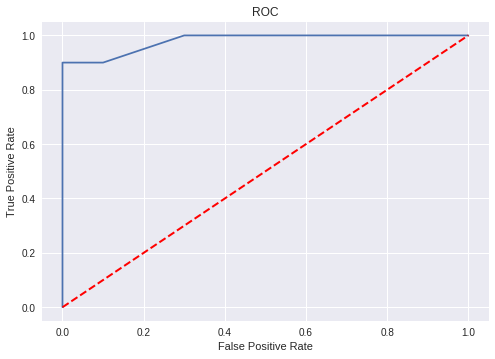

In [58]:
import matplotlib.pyplot as plt

plt.plot(fpr.T, tpr.T);
plt.plot([0, 1], [0, 1], 'r--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC');

## ROC using sklearn
[documentation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html)

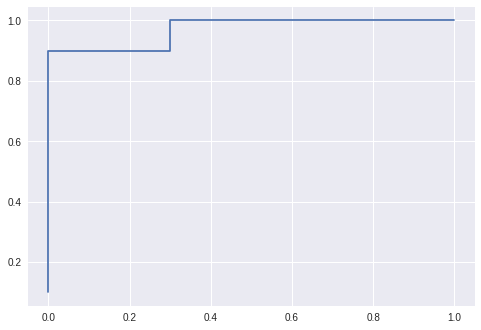

In [60]:
from sklearn import metrics

fpr, tpr, _ = metrics.roc_curve(y_train.values, proba[:, 1:])
plt.plot(fpr, tpr);

**Note:** close enough, the difference is because of the different number of points we taken to calculate the FPR and TPR at

# Let's try the same on Test set

In [61]:
proba = regr.predict_proba(x_test)
print(proba)

[[0.91546684 0.08453316]
 [0.05621615 0.94378385]
 [0.47598139 0.52401861]
 [0.09151874 0.90848126]
 [0.02440489 0.97559511]
 [0.76625685 0.23374315]
 [0.69463891 0.30536109]
 [0.03119646 0.96880354]
 [0.95973223 0.04026777]
 [0.0149007  0.9850993 ]
 [0.41669665 0.58330335]
 [0.75430429 0.24569571]
 [0.72499976 0.27500024]
 [0.30588658 0.69411342]
 [0.88800316 0.11199684]
 [0.74656536 0.25343464]
 [0.23471265 0.76528735]
 [0.76149711 0.23850289]
 [0.39322886 0.60677114]
 [0.72155744 0.27844256]]


In [62]:
thresholds = np.linspace(0.0, 1.0, 11)
predictions = pd.DataFrame()

for each in thresholds:
  decision_threshold = np.round(each, 2)
  y_pred = (proba[:, 1:] > decision_threshold).T[0]
  predictions[str(decision_threshold)] = y_pred.astype(int)

predictions

,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0,1,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,0
2,1,1,1,1,1,1,0,0,0,0,0
3,1,1,1,1,1,1,1,1,1,1,0
4,1,1,1,1,1,1,1,1,1,1,0
5,1,1,1,0,0,0,0,0,0,0,0
6,1,1,1,1,0,0,0,0,0,0,0
7,1,1,1,1,1,1,1,1,1,1,0
8,1,0,0,0,0,0,0,0,0,0,0
9,1,1,1,1,1,1,1,1,1,1,0


In [63]:
fpr = pd.DataFrame()
tpr = pd.DataFrame()
for threshold in predictions.columns:
  fpr[threshold] = pd.Series(np.sum((predictions[threshold] - y_test.values) == 1) / np.sum(y_test == 0))
  tpr[threshold] = pd.Series(np.sum((predictions[threshold] + y_test.values) == 2) / np.sum(y_test == 1))

print('False Positive Rate')
print(fpr.T)
print()
print('True Positive Rate')
print(tpr.T)

False Positive Rate
       0
0.0  1.0
0.1  0.8
0.2  0.7
0.3  0.1
0.4  0.1
0.5  0.1
0.6  0.0
0.7  0.0
0.8  0.0
0.9  0.0
1.0  0.0

True Positive Rate
       0
0.0  1.0
0.1  1.0
0.2  1.0
0.3  1.0
0.4  0.9
0.5  0.9
0.6  0.8
0.7  0.6
0.8  0.5
0.9  0.5
1.0  0.0


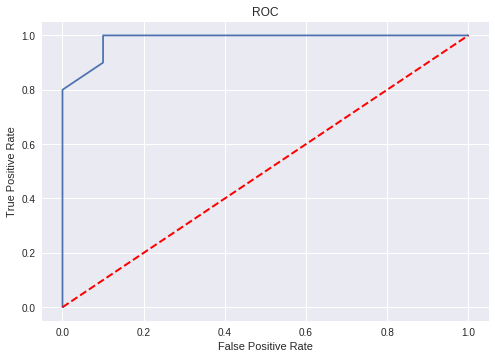

In [64]:
plt.plot(fpr.T, tpr.T);
plt.plot([0, 1], [0, 1], 'r--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC');

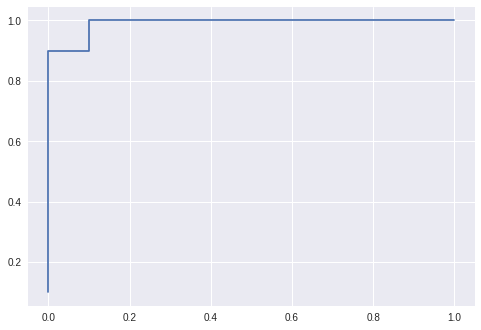

In [66]:
fpr, tpr, _ = metrics.roc_curve(y_test.values, proba[:, 1:])
plt.plot(fpr, tpr);